# Consumer Complaints NLP Analysis
### Natural Language Processing — Topic Modeling, Urgency Detection & 4-Level Classification
<pre>
Class : INFO-6148-Naturl Language Processing  
Professor : Fatemeh Dehrouyeh  
Program : AIM1  
Student ID :1319840  
Student Name : Edward (Seongmin Choi)  
</pre>
Dataset: [Consumer Complaints - Financial products](https://www.kaggle.com/datasets/ashwinik/consumer-complaints-financial-products)  


## 📋 Objectives
1. Stopword Processing — NLTK + custom financial domain stopwords
2. Urgency Detection — Rule-based scoring + ML urgency classification (4 levels)
3. 4-Level Complaint Classification — Product → Sub-product → Issue → Sub-issue
4. Topic Modeling with BERTopic — Unsupervised topic extraction from complaint narratives
5. Test Inference — New complaint text → urgency + classification

---
## Cell 1 — Install Required Packages

In [13]:
import importlib.util
import subprocess
import sys

def install_if_missing(package_name, pip_name=None):
    if pip_name is None:
        pip_name = package_name
    spec = importlib.util.find_spec(package_name)
    if spec is None:
        print(f"Installing {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name, "-q"])
    else:
        print(f"{package_name} already installed.")

packages = [
    ("nltk",            "nltk"),
    ("sklearn",         "scikit-learn"),
    ("bertopic",        "bertopic"),
    ("sentence_transformers", "sentence-transformers"),
    ("umap",            "umap-learn"),
    ("hdbscan",         "hdbscan"),
    ("plotly",          "plotly"),
    ("seaborn",         "seaborn"),
]

for pkg, pip in packages:
    install_if_missing(pkg, pip)

nltk already installed.
sklearn already installed.
bertopic already installed.
sentence_transformers already installed.
umap already installed.
hdbscan already installed.
plotly already installed.
seaborn already installed.


---
## Cell 2 — Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download NLTK resources
for resource in ['stopwords', 'punkt', 'punkt_tab', 'wordnet', 'averaged_perceptron_tagger']:
    nltk.download(resource, quiet=True)

print("All libraries imported successfully.")

All libraries imported successfully.


---
## Cell 3 — Load & Explore Data

In [15]:
# ── Load data ──────────────────────────────────────────────────────────────
# Adjust path if running locally
DATA_PATH = "Consumer_Complaints_dn.csv"

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head(3)

Dataset shape: (114704, 18)

Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,05/15/2015,Credit card,NaN,Billing disputes,NaN,-- -- -- -- -- Forwarded message -- -- -- -- -...,NaN,Capital One,CA,920XX,NaN,Consent provided,Web,05/19/2015,Closed with explanation,Yes,Yes,1378763
1,04/24/2015,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,- called Ally Auto to have a deferred payment ...,Company chooses not to provide a public response,Ally Financial Inc.,FL,347XX,NaN,Consent provided,Web,04/24/2015,Closed with non-monetary relief,Yes,No,1345623
2,05/27/2015,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,- Continuous harassment - Threats of repossess...,Company chooses not to provide a public response,Ally Financial Inc.,NY,118XX,NaN,Consent provided,Web,05/27/2015,Closed with explanation,Yes,No,1394849


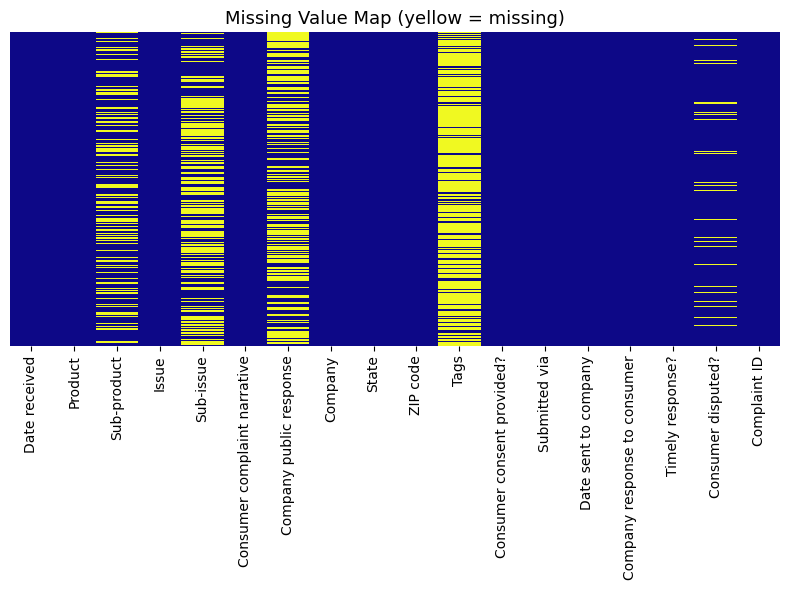

Product                                        114704 / 114704  (100.0%)
Sub-product                                    78920 / 114704  (68.8%)
Issue                                          114704 / 114704  (100.0%)
Sub-issue                                      57256 / 114704  (49.9%)
Consumer complaint narrative                   114704 / 114704  (100.0%)


In [16]:
# ── Missing value heatmap ──────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
sns.heatmap(df.isnull(), cmap='plasma', cbar=False, yticklabels=False)
plt.title("Missing Value Map (yellow = missing)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Classification column coverage ────────────────────────────────────────
for col in ['Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative']:
    available = df[col].notna().sum()
    print(f"{col:45s}  {available:5d} / {len(df):5d}  ({available/len(df)*100:.1f}%)")

---
## Cell 4 — Stopword Processing 
> NLTK basic stopword + custom stopword (Financial domain) + remove masking token (XXXX)

In [17]:
# ── 1. NLTK English stopwords ─────────────────────────────────────────────
base_stopwords = set(stopwords.words('english'))

# ── 2. CFPB dataset specific masking tokens ───────────────────────────────
masking_tokens = {
    'xx', 'xxx', 'xxxx', 'xxxxx', 'xxxxxx', 'xxxxxxx',
    'xxxxxxxx', 'xxxxxxxxx', 'xxxxxxxxxx', 'xxxxxxxxxxx', 'xxxxxxxxxxxx' 
}

# ── 3. Financial domain stopwords ─────────────────────────────────────────
financial_stopwords = {
    # Generic complaint words (no discriminative power)
    'company', 'account', 'would', 'also', 'said', 'told', 'call',
    'called', 'get', 'got', 'one', 'us', 'made', 'make', 'time',
    'since', 'even', 'still', 'back', 'know', 'many', 'could',
    'contact', 'contacted', 'send', 'sent', 'received', 'receive',
    # Regulatory boilerplate
    'cfpb', 'consumer', 'complaint', 'financial', 'bureau',
    'protection', 'federal', 'act', 'law',
    # Date/number noise
    'january', 'february', 'march', 'april', 'may', 'june',
    'july', 'august', 'september', 'october', 'november', 'december',
    'month', 'year', 'day', 'date',
    # Generic financial terms too common to distinguish
    'bank', 'money', 'payment', 'paid', 'pay', 'amount',
    'letter', 'information', 'number', 'please',
}

# ── 4. Combine all stopwords ───────────────────────────────────────────────
ALL_STOPWORDS = base_stopwords | masking_tokens | financial_stopwords

print(f"Base NLTK stopwords   : {len(base_stopwords):4d}")
print(f"Masking tokens        : {len(masking_tokens):4d}")
print(f"Financial stopwords   : {len(financial_stopwords):4d}")
print(f"Total unique stopwords: {len(ALL_STOPWORDS):4d}")

# ── 5. Text preprocessing function ────────────────────────────────────────
lemmatizer = WordNetLemmatizer()

def preprocess_text(text, remove_stopwords=True):
    """
    Full NLP preprocessing pipeline:
    lowercase → remove special chars → tokenize → stopword removal → lemmatization
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove special characters, keep only alphanumeric + spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # 3. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 4. Tokenize
    tokens = word_tokenize(text)
    
    # 5. Stopword removal
    if remove_stopwords:
        tokens = [t for t in tokens if t not in ALL_STOPWORDS and len(t) > 2]
    
    # 6. Lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    return ' '.join(tokens)

# Demo
sample_raw = df['Consumer complaint narrative'].dropna().iloc[0]
sample_processed = preprocess_text(sample_raw)
print(f"\n--- Raw text (first 300 chars) ---")
print(sample_raw[:300])
print(f"\n--- After preprocessing (first 300 chars) ---")
print(sample_processed[:300])

Base NLTK stopwords   :  198
Masking tokens        :   11
Financial stopwords   :   63
Total unique stopwords:  272

--- Raw text (first 300 chars) ---
-- -- -- -- -- Forwarded message -- -- -- -- -- From : " XXXX XXXX '' & lt ; XXXXXXXXXXXX & gt ; Date : XXXX XXXX, 2015 XXXX XXXXSubject : To : & lt ; XXXXXXXXXXXX & gt ; Cc : On attempt to file tax forms with taxslayer a site recommended by irs. When try to pay for state XXXX with my cap one ccard 

--- After preprocessing (first 300 chars) ---
forwarded message xxxxsubject attempt file tax form taxslayer site recommended irs try state cap ccard gave pop action complete check retry upon seeing info correct attempt gave error msg code taxslayer closed curious ckecked cap mobile app showed pending taxslayer taxslayer try automated system see


---
## Cell 5 — Data Cleaning & Preprocessing

In [28]:
# ── Keep rows that have at least a narrative OR Product label ──────────────
df_clean = df.copy()

# Fill missing classification labels with 'Unknown'
for col in ['Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer disputed?']:
    df_clean[col] = df_clean[col].fillna('Unknown')

# For narrative-based tasks, filter rows WITH narratives
df_narr = df_clean.dropna(subset=['Consumer complaint narrative']).copy()
print(f"Rows with narrative: {len(df_narr)} / {len(df_clean)}")

# Apply preprocessing to narratives
print("Preprocessing complaint narratives...")
df_narr['processed_text'] = df_narr['Consumer complaint narrative'].apply(preprocess_text)

# Remove empty results
df_narr = df_narr[df_narr['processed_text'].str.len() > 10].reset_index(drop=True)
print(f"After preprocessing: {len(df_narr)} rows")

print("\nData preparation complete.")
df_narr[['Product', 'Sub-product', 'Issue', 'Sub-issue', 'processed_text']].head(3)

Rows with narrative: 114704 / 114704
Preprocessing complaint narratives...
After preprocessing: 114555 rows

Data preparation complete.


,Product,Sub-product,Issue,Sub-issue,processed_text
0,Credit card,Unknown,Billing disputes,Unknown,forwarded message xxxxsubject attempt file tax...
1,Consumer Loan,Vehicle loan,Managing the loan or lease,Unknown,ally auto deferred ally auto pair partial requ...
2,Consumer Loan,Vehicle loan,Managing the loan or lease,Unknown,continuous harassment threat repossession vehi...


---
## Cell 6 — EDA: Category Distribution

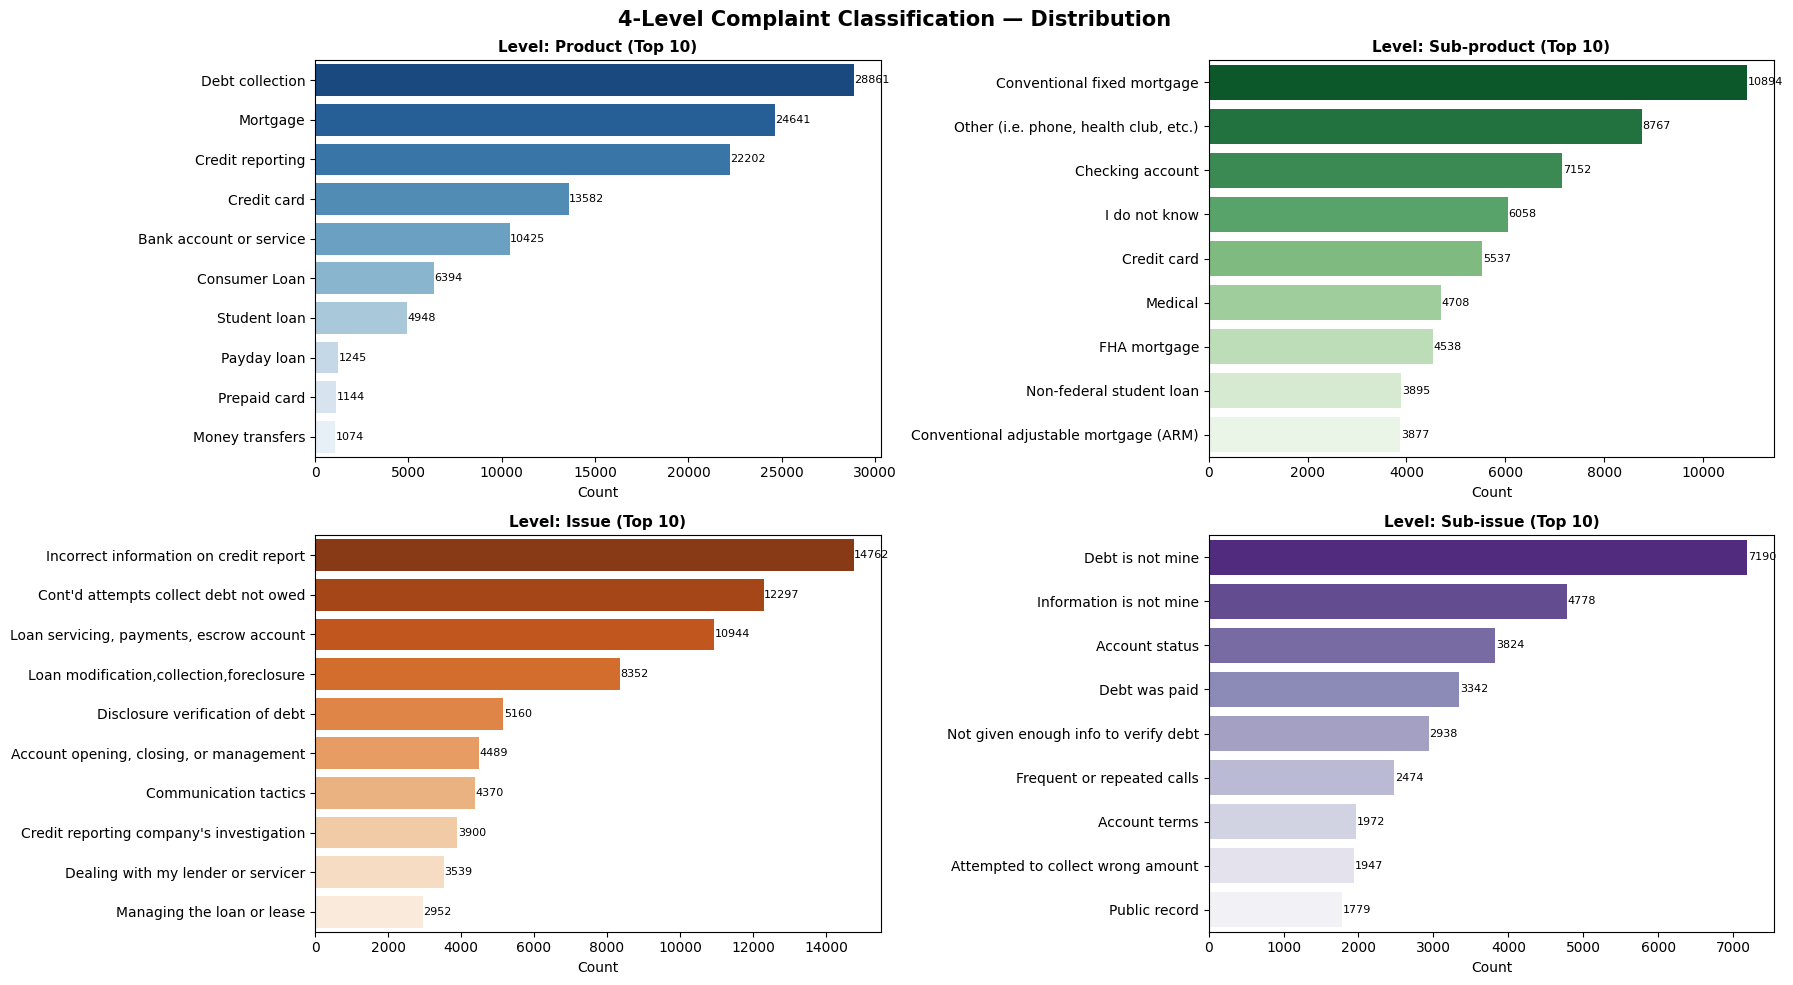


Unique values per level:
  Product        : 12 unique categories
  Sub-product    : 47 unique categories
  Issue          : 90 unique categories
  Sub-issue      : 65 unique categories


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("4-Level Complaint Classification — Distribution", fontsize=15, fontweight='bold')

cols = ['Product', 'Sub-product', 'Issue', 'Sub-issue']
palettes = ['Blues_r', 'Greens_r', 'Oranges_r', 'Purples_r']

for ax, col, pal in zip(axes.flatten(), cols, palettes):
    counts = df_clean[col].value_counts().head(10)
    # Filter out 'Unknown' for cleaner display
    counts = counts[counts.index != 'Unknown'].head(10)
    sns.barplot(x=counts.values, y=counts.index, ax=ax, palette=pal)
    ax.set_title(f"Level: {col} (Top 10)", fontsize=11, fontweight='bold')
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}',
                    (p.get_width() + 10, p.get_y() + p.get_height() / 2),
                    ha='left', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nUnique values per level:")
for col in cols:
    n = df_clean[col].nunique()
    print(f"  {col:15s}: {n} unique categories")

---
## Cell 7 — Urgency Scoring
> Calculate **Level 4 Urgency** based on 5 response result columns
>
> | Column Name | Urgency assessment role |
> |---|---|
> | `Company public response` | Whether the company denies liability, disputes, or admits errors |
> | `Consumer consent provided?` | Restriction on information access without consent → Potential disadvantages |
> | `Company response to consumer` | Untimely / In progress / Monetary relief |
> | `Timely response?` | No → Immediate response needed |
> | `Consumer disputed?` | Yes → Unsatisfactory resolution, reprocessing needed |
>
> | Level | Label | Description |
> |---|---|---|
> | 4 | 🔴 CRITICAL | Delayed Response + Dispute + Company Disclaimer |
> | 3 | 🟠 HIGH | Financial Relief / Dispute / Untimely Solo Occurrence |
> | 2 | 🟡 MEDIUM | Partial risk, such as in progress or lack of consent |
> | 1 | 🟢 LOW | Normal conclusion, timely response, no disputes |

In [20]:
# ════════════════════════════════════════════════════════════════════
# Urgency scoring 
#
# Column-by-column scoring design (maximum sum of 20 points)
# ┌─────────────────────────────────────┬────────────────────────────────────┬───────┐
# │ Column                              │ Value                              │ Score │
# ├─────────────────────────────────────┼────────────────────────────────────┼───────┤
# │ Timely response?                    │ No                                 │  +6   │
# │                                     │ Yes                                │   0   │
# ├─────────────────────────────────────┼────────────────────────────────────┼───────┤
# │ Consumer disputed?                  │ Yes                                │  +4   │
# │                                     │ No / NaN                           │   0   │
# ├─────────────────────────────────────┼────────────────────────────────────┼───────┤
# │ Company response to consumer        │ Untimely response                  │  +6   │
# │                                     │ In progress                        │  +3   │
# │                                     │ Closed with monetary relief        │  +2   │
# │                                     │ Closed with non-monetary relief    │  +1   │
# │                                     │ Closed without relief              │  +1   │
# │                                     │ Closed / Closed with explanation   │   0   │
# ├─────────────────────────────────────┼────────────────────────────────────┼───────┤
# │ Company public response             │ disputes the facts                 │  +3   │
# │                                     │ can't verify or dispute            │  +2   │
# │                                     │ misunderstanding                   │  +1   │
# │                                     │ isolated error                     │  +1   │
# │                                     │ third party / improvement          │  +1   │
# │                                     │ acted appropriately / no public    │   0   │
# │                                     │ NaN (no public statement)          │   0   │
# ├─────────────────────────────────────┼────────────────────────────────────┼───────┤
# │ Consumer consent provided?          │ Consent not provided               │  +1   │
# │                                     │ Other                              │  +1   │
# │                                     │ Consent provided / NaN             │   0   │
# └─────────────────────────────────────┴────────────────────────────────────┴───────┘
#
# Urgency level criteria
#   CRITICAL (4) : score >= 10
#   HIGH     (3) : score >= 6
#   MEDIUM   (2) : score >= 2
#   LOW      (1) : score <  2
# ════════════════════════════════════════════════════════════════════

# ── 1. Company response to consumer Score mapping ───────────────────────
COMPANY_RESPONSE_SCORE = {
    'Untimely response'                 : 6,    # Most serious: Violation of legal duty to respond
    'In progress'                       : 3,    # Still unresolved → indicates ongoing issue
    'Closed with monetary relief'       : 2,    # Monetary compensation → Recognition of actual damages
    'Closed with non-monetary relief'   : 1,    # Non-monetary relief → Partial acknowledgment
    'Closed without relief'             : 1,    # No relief provided → Consumer dissatisfaction possible
    'Closed with relief'                : 1,    # Relief provided after closure (minority)
    'Closed with explanation'           : 0,    # Closure with explanation → Normal handling
    'Closed'                            : 0,    # Simple closure
}

# ── 2. Company public response point mapping ─────────────────────────────────
def score_public_response(val):
    """ Scoring how disadvantageous the company's public stance is to consumers """
    v = str(val).lower()
    if 'disputes the facts' in v:
        return 3   # Denying the fact itself → Most disadvantageous to the consumer
    if "can't verify or dispute" in v:
        return 2   # Unable to verify → Difficult to resolve
    if 'misunderstanding' in v:
        return 1   # Claiming it is a misunderstanding → Implying consumer fault
    if 'isolated error' in v:
        return 1   # Acknowledging a one-time error → Minor
    if 'third party' in v or 'improvement' in v:
        return 1   # Avoiding responsibility or acknowledging room for improvement
    # 'acted appropriately', 'chooses not to provide', NaN → Normal/Neutral
    return 0

# ── 3. Integrated urgency score function ──────────────────────────────────────────────
def compute_urgency_score(row):
    """
    Rule-based urgency score using only 5 response result columns.
    Utilizes only structured metadata without relying on text (narrative).

    Parameters
    ----------
    row : dict or pd.Series
        Must include the following keys:
        - 'Timely response?'
        - 'Consumer disputed?'
        - 'Company response to consumer'
        - 'Company public response'
        - 'Consumer consent provided?'

    Returns
    -------
    int : urgency score (0 ~ 20)
    """
    score = 0

    # ── (A) Timely response? ───────────────────────────────────────────────
    # Mandatory response within 15 days under CFPB regulations. 'No' = Urgent signal amounting to a legal violation.
    timely = str(row.get('Timely response?', 'Yes')).strip()
    if timely == 'No':
        score += 6

    # ── (B) Consumer disputed? ────────────────────────────────────────────
    # Consumer disputed the company's resolution → Need for reprocessing/escalation
    disputed = str(row.get('Consumer disputed?', 'No')).strip()
    if disputed == 'Yes':
        score += 4

    # ── (C) Company response to consumer ──────────────────────────────────
    company_resp = str(row.get('Company response to consumer', '')).strip()
    score += COMPANY_RESPONSE_SCORE.get(company_resp, 0)

    # ── (D) Company public response ───────────────────────────────────────
    public_resp = row.get('Company public response', '')
    score += score_public_response(public_resp)

    # ── (E) Consumer consent provided? ────────────────────────────────────
    # Failure to provide consent → Unclear resolution as the company cannot publicly refute the narrative
    consent = str(row.get('Consumer consent provided?', '')).strip()
    if consent in ('Consent not provided', 'Other'):
        score += 1

    return score

# ── 4. urgency score → 4-level label conversion ────────────────────────────────────────────
def score_to_urgency_level(score):
    """Map numeric score to 4-level urgency label."""
    if score >= 10:
        return 4  # CRITICAL
    elif score >= 6:
        return 3  # HIGH
    elif score >= 2:
        return 2  # MEDIUM
    else:
        return 1  # LOW

URGENCY_LABELS = {
    4: '🔴 CRITICAL',
    3: '🟠 HIGH',
    2: '🟡 MEDIUM',
    1: '🟢 LOW',
}

# ── 5.  ───────────────────────────────────────────────
df_clean['urgency_score'] = df_clean.apply(compute_urgency_score, axis=1)
df_clean['urgency_level'] = df_clean['urgency_score'].apply(score_to_urgency_level)
df_clean['urgency_label'] = df_clean['urgency_level'].map(URGENCY_LABELS)

# ── 6. Check column contribution (for diagnosis) ─────────────────────────────────────────
print("=" * 55)
print("  Urgency Score Distribution")
print("=" * 55)
print(df_clean['urgency_label'].value_counts().to_string())
print(f"\nAvg urgency score : {df_clean['urgency_score'].mean():.2f}")
print(f"Max urgency score : {df_clean['urgency_score'].max()}")
print()

# Urgency score contribution status by column
print("─" * 55)
print("  Column-level contribution (mean score added):")
print("─" * 55)
timely_contrib    = df_clean.apply(lambda r: 6 if str(r.get('Timely response?','Yes'))=='No' else 0, axis=1).mean()
disputed_contrib  = df_clean.apply(lambda r: 4 if str(r.get('Consumer disputed?','No'))=='Yes' else 0, axis=1).mean()
cresp_contrib     = df_clean.apply(lambda r: COMPANY_RESPONSE_SCORE.get(str(r.get('Company response to consumer','')).strip(), 0), axis=1).mean()
pubr_contrib      = df_clean.apply(lambda r: score_public_response(r.get('Company public response','')), axis=1).mean()
consent_contrib   = df_clean.apply(lambda r: 1 if str(r.get('Consumer consent provided?','')) in ('Consent not provided','Other') else 0, axis=1).mean()

for label, val in [
    ('Timely response? (max 6)',               timely_contrib),
    ('Consumer disputed? (max 4)',             disputed_contrib),
    ('Company response to consumer (max 6)',   cresp_contrib),
    ('Company public response (max 3)',        pubr_contrib),
    ('Consumer consent provided? (max 1)',     consent_contrib),
]:
    print(f"  {label:42s}: {val:.3f}")

  Urgency Score Distribution
urgency_label
🟢 LOW         76071
🟡 MEDIUM      33126
🟠 HIGH         3963
🔴 CRITICAL     1544

Avg urgency score : 1.53
Max urgency score : 13

───────────────────────────────────────────────────────
  Column-level contribution (mean score added):
───────────────────────────────────────────────────────
  Timely response? (max 6)                  : 0.212
  Consumer disputed? (max 4)                : 0.922
  Company response to consumer (max 6)      : 0.322
  Company public response (max 3)           : 0.068
  Consumer consent provided? (max 1)        : 0.000


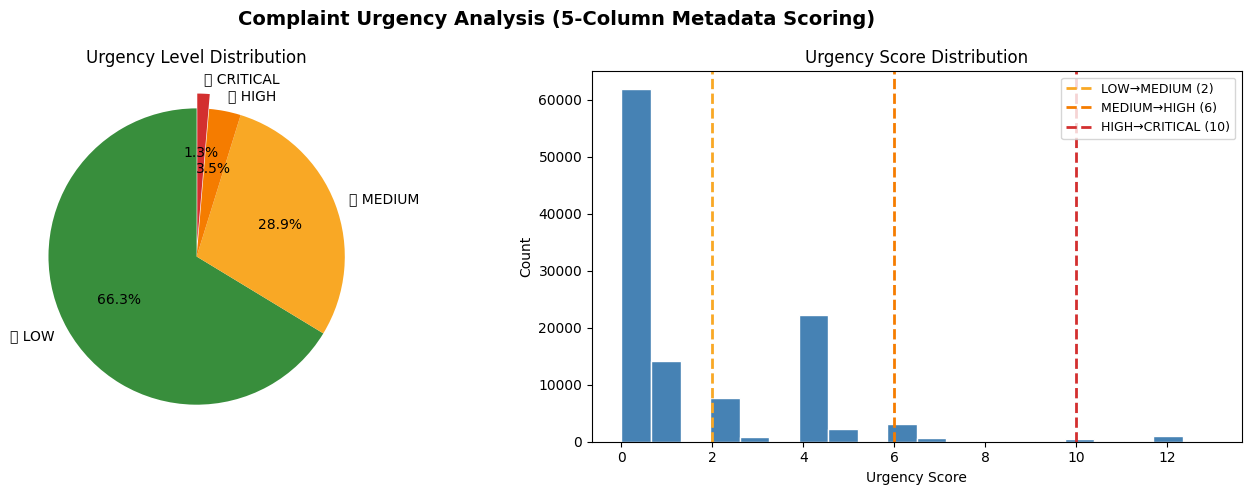

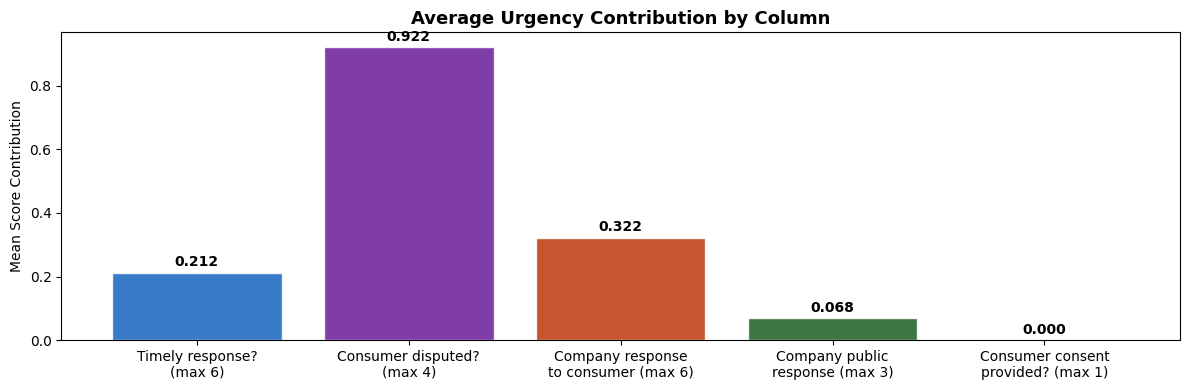

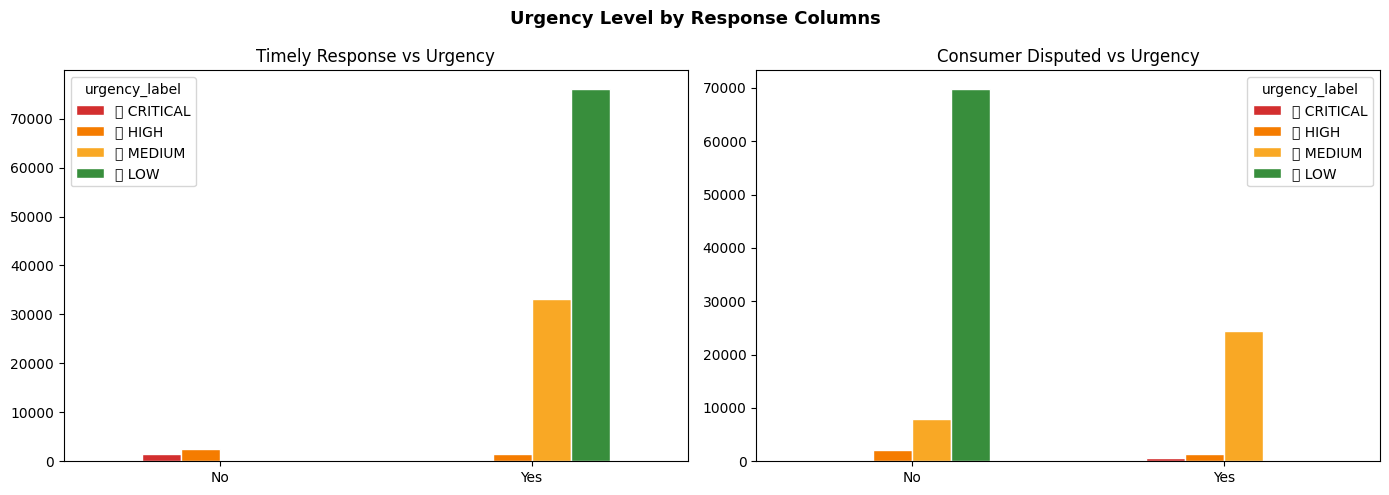

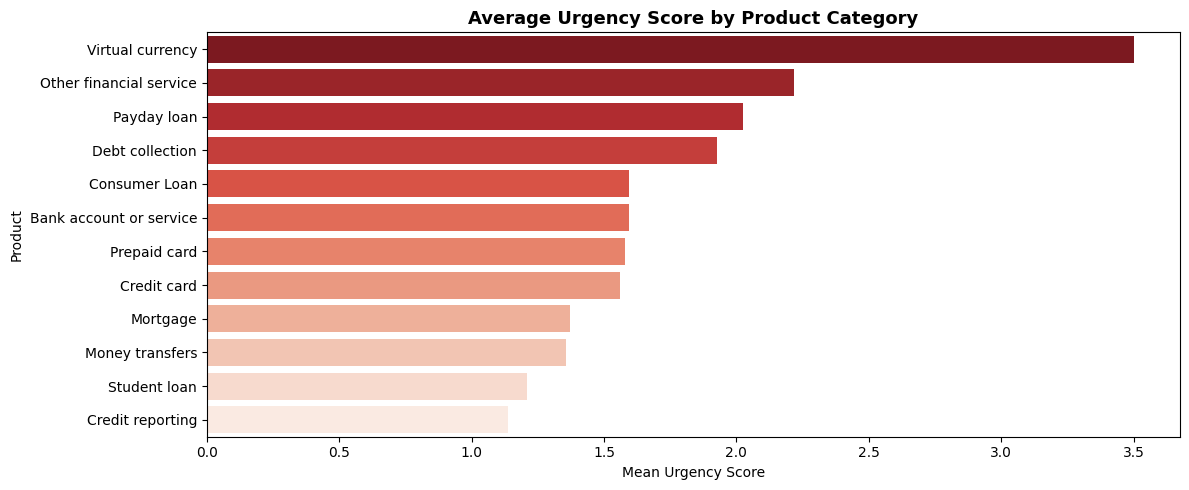

In [21]:
# ── Visualize urgency distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Complaint Urgency Analysis (5-Column Metadata Scoring)",
             fontsize=14, fontweight='bold')

# Pie chart
urgency_counts = df_clean['urgency_label'].value_counts()
colors = ['#388e3c', '#f9a825', '#f57c00', '#d32f2f']
explode = [0, 0, 0.0, 0.1]
axes[0].pie(
    urgency_counts.values,
    labels=urgency_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=explode
)
axes[0].set_title("Urgency Level Distribution")

# Score histogram
axes[1].hist(df_clean['urgency_score'], bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(x=2,  color='#f9a825', linewidth=2, linestyle='--', label='LOW→MEDIUM (2)')
axes[1].axvline(x=6,  color='#f57c00', linewidth=2, linestyle='--', label='MEDIUM→HIGH (6)')
axes[1].axvline(x=10, color='#d32f2f', linewidth=2, linestyle='--', label='HIGH→CRITICAL (10)')
axes[1].set_xlabel("Urgency Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Urgency Score Distribution")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Bar chart of average contribution by column ────────────────────────────────────────────
contrib_labels = [
    'Timely response?\n(max 6)',
    'Consumer disputed?\n(max 4)',
    'Company response\nto consumer (max 6)',
    'Company public\nresponse (max 3)',
    'Consumer consent\nprovided? (max 1)',
]
contrib_values = [timely_contrib, disputed_contrib, cresp_contrib,
                  pubr_contrib, consent_contrib]
contrib_colors = ['#1565C0', '#6A1B9A', '#BF360C', '#1B5E20', '#4E342E']

fig2, ax2 = plt.subplots(figsize=(12, 4))
bars = ax2.bar(contrib_labels, contrib_values,
               color=contrib_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, contrib_values):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f"{val:.3f}", ha='center', va='bottom', fontweight='bold', fontsize=10)
ax2.set_ylabel("Mean Score Contribution")
ax2.set_title("Average Urgency Contribution by Column",
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Bar chart of urgency level by response columns ────────────────────────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))
fig3.suptitle("Urgency Level by Response Columns", fontsize=13, fontweight='bold')

# Timely response vs Urgency
timely_urg = df_clean.groupby(['Timely response?', 'urgency_label']).size().unstack(fill_value=0)
timely_urg.plot(kind='bar', ax=axes3[0], color=['#d32f2f','#f57c00','#f9a825','#388e3c'],
                edgecolor='white', legend=True)
axes3[0].set_title("Timely Response vs Urgency")
axes3[0].set_xlabel("")
axes3[0].tick_params(axis='x', rotation=0)

# Consumer disputed vs Urgency
disp_urg = df_clean.groupby(['Consumer disputed?', 'urgency_label']).size().unstack(fill_value=0)
disp_urg.plot(kind='bar', ax=axes3[1], color=['#d32f2f','#f57c00','#f9a825','#388e3c'],
              edgecolor='white', legend=True)
axes3[1].set_title("Consumer Disputed vs Urgency")
axes3[1].set_xlabel("")
axes3[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Urgency by Product (Average)
plt.figure(figsize=(12, 5))
urgency_by_product = (
    df_clean[df_clean['Product'] != 'Unknown']
    .groupby('Product')['urgency_score']
    .mean()
    .sort_values(ascending=False)
)
sns.barplot(x=urgency_by_product.values, y=urgency_by_product.index, palette='Reds_r')
plt.title("Average Urgency Score by Product Category", fontsize=13, fontweight='bold')
plt.xlabel("Mean Urgency Score")
plt.tight_layout()
plt.show()

---
## Cell 8 — 4-Level Classification Models
> TF-IDF + Logistic Regression pipeline for each level  
> Level 1 (Product) → Level 2 (Sub-product) → Level 3 (Issue) → Level 4 (Sub-issue)

In [22]:
from sklearn.metrics import roc_curve, auc
# ── Build training data for classification ─────────────────────────────────
# Use narrative rows for text classification
df_cls = df_narr.copy()

# Synchronize urgency labels to df_narr index
df_cls['urgency_score'] = df_cls.index.map(
    lambda i: compute_urgency_score(df_cls.loc[i])
)
df_cls['urgency_level'] = df_cls['urgency_score'].apply(score_to_urgency_level)

# ── Classification pipeline builder ───────────────────────────────────────
def build_classifier(X_train, y_train):
    """TF-IDF + Logistic Regression pipeline."""
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=15000,
            ngram_range=(1, 2),
            sublinear_tf=True,
            stop_words=list(ALL_STOPWORDS),
            min_df=2,
        )),
        ('clf', LogisticRegression(
            max_iter=1000,
            C=1.0,
            solver='lbfgs',
            multi_class='multinomial',
            n_jobs=-1,
        ))
    ])
    pipe.fit(X_train, y_train)
    return pipe

# ── Train models per classification level ─────────────────────────────────
classifiers = {}
label_encoders = {}
level_results = {}

LEVELS = [
    ('Product',     'Level 1'),
    ('Sub-product', 'Level 2'),
    ('Issue',       'Level 3'),
    ('Sub-issue',   'Level 4'),
]

for col, level_name in LEVELS:
    print(f"Training {level_name}: {col}")
    
    # Filter: enough samples per class (at least 5)
    class_counts = df_cls[col].value_counts()
    valid_classes = class_counts[class_counts >= 5].index.tolist()
    
    df_level = df_cls[df_cls[col].isin(valid_classes)].copy()
    
    if len(df_level) < 50 or df_level[col].nunique() < 2:
        print(f"Not enough data for {col}. Skipping.")
        classifiers[col] = None
        continue
    
    X = df_level['processed_text'].values
    y = df_level[col].values
    
    # Label encode
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    label_encoders[col] = le
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )
    
    # Build & train
    clf = build_classifier(X_train, y_train)
    classifiers[col] = clf
    
    # Evaluate
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = classification_report(y_test, y_pred, output_dict=True)['weighted avg'].values()

    # # ROC-AUC
    # y_scores = clf.predict_proba(X_test)[:,1]
    # fpr, tpr, thresholds = roc_curve(y_test, y_scores, pos_label=1)
    # roc_auc = auc(fpr, tpr)
    
    level_results[col] = {
        'accuracy': acc,
        'n_classes': len(valid_classes),
        'n_samples': len(df_level),
        'precision': precision,
        'recall': recall,
        'f1': f1
        # 'fpr': fpr,
        # 'tpr': tpr,
        # 'roc_auc': roc_auc
    }
    
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
summary_df = pd.DataFrame(level_results).T
print(summary_df)



print("\nAll classification models trained.")

Training Level 1: Product
Training Level 2: Sub-product
Training Level 3: Issue
Training Level 4: Sub-issue
             accuracy  n_classes  n_samples  precision  recall   f1
Product          0.86      12.00  114555.00       0.86    0.86 0.86
Sub-product      0.67      46.00  114553.00       0.65    0.67 0.64
Issue            0.58      87.00  114549.00       0.55    0.58 0.55
Sub-issue        0.69      65.00  114555.00       0.64    0.69 0.65

All classification models trained.


In [23]:
# ROC curve comparison across levels
# plt.figure(figsize=(10, 7))
# lw = 2  

# for level_name, metrics in level_results.items():    
#     if metrics['fpr'] is not None and metrics['tpr'] is not None:
#         plt.plot(
#             metrics['fpr'], 
#             metrics['tpr'], 
#             lw=lw, 
#             label=f"{level_name} (AUC = {metrics['roc_auc']:.3f})"
#         )

# # threshold line for random guessing
# plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')

# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate (FPR)')
# plt.ylabel('True Positive Rate (TPR)')
# plt.title('Multi-level Classification ROC Curves Comparison')
# plt.legend(loc="lower right")
# plt.grid(alpha=0.3)

# plt.tight_layout()
# plt.show()

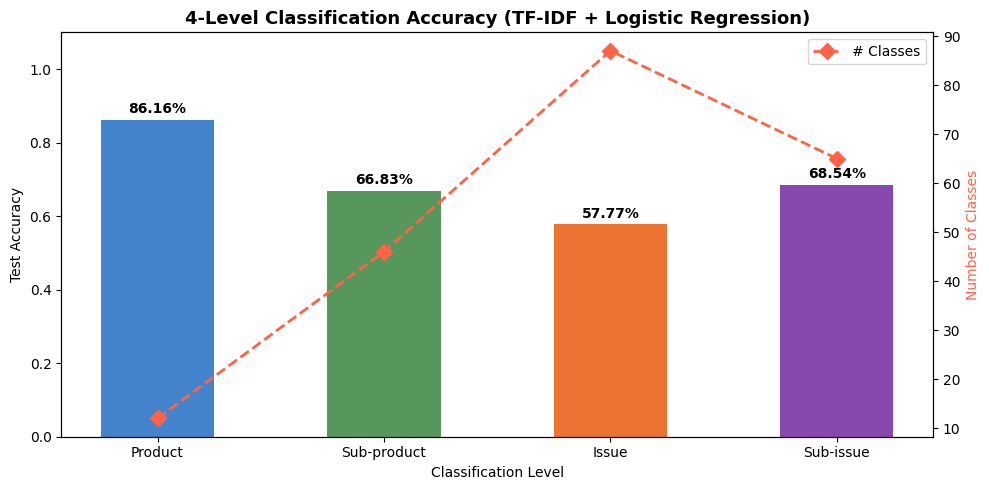

In [24]:
# ── Accuracy comparison bar chart ─────────────────────────────────────────
level_names = list(level_results.keys())
accuracies  = [level_results[k]['accuracy'] for k in level_names]
n_classes   = [level_results[k]['n_classes'] for k in level_names]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

bars = ax1.bar(
    level_names, accuracies,
    color=['#1565C0', '#2E7D32', '#E65100', '#6A1B9A'],
    alpha=0.8, width=0.5
)
for bar, acc in zip(bars, accuracies):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc:.2%}", ha='center', va='bottom', fontweight='bold'
    )

ax2.plot(level_names, n_classes, 'D--', color='tomato',
         linewidth=2, markersize=8, label='# Classes')
ax2.set_ylabel("Number of Classes", color='tomato')

ax1.set_xlabel("Classification Level")
ax1.set_ylabel("Test Accuracy")
ax1.set_ylim(0, 1.1)
ax1.set_title("4-Level Classification Accuracy (TF-IDF + Logistic Regression)",
              fontsize=13, fontweight='bold')

ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [25]:
def predict_complaint(raw_text):
    # 1. preprocess the input text
    processed = preprocess_text(raw_text)
    
    print(f"Input Text: {raw_text[:100]}...")
    print(f"Processed: {processed}")
    print("-" * 50)
    
    results = {}
    
    # 2. Predict (Product, Sub-product, Issue, Sub-issue)
    for col, level_name in LEVELS:
        clf = classifiers.get(col)
        le = label_encoders.get(col)
        
        if clf and le:
            # predict probability
            prob = clf.predict_proba([processed])
            pred_idx = prob.argmax()
            confidence = prob.max()
            
            # transform index back to actual label
            label = le.inverse_transform([pred_idx])[0]
            results[level_name] = f"{label} ({confidence*100:.1f}%)"
        else:
            results[level_name] = "Not Trained"

    # 3. Compute Urgency Score (Create temporary DataFrame to use existing logic)
    # In a real environment, product group information would be needed, so we create a mock row with the predicted Product and default values for other columns
    temp_row = pd.Series({
        'processed_text': processed,
        'Product': results.get('Level 1', '').split(' (')[0]
    })
    
    
    u_score = compute_urgency_score(temp_row)
    u_level = score_to_urgency_level(u_score)
    
    # Display results
    print(f"[Urgency] Score: {u_score:.2f} / Level: {u_level}")
    for level, res in results.items():
        print(f"[{level}] {res}")
        
    return results

In [26]:
# Test cases :  Credit card annual fee dispute (medium urgency)
test_text_1 = "My credit card was charged an annual fee of $99 even though I was promised it would be waived for the first year. This is unacceptable."

# test case 2: Foreclosure threat due to bank error (high urgency)
test_text_2 = "I am at risk of losing my home because the bank miscalculated my mortgage payments and is now threatening foreclosure. I need immediate help."

print("--- Test 1 ---")
predict_complaint(test_text_1)

print("\n--- Test 2 ---")
predict_complaint(test_text_2)

--- Test 1 ---
Input Text: My credit card was charged an annual fee of $99 even though I was promised it would be waived for th...
Processed: credit card charged annual fee though promised waived first unacceptable
--------------------------------------------------
[Urgency] Score: 0.00 / Level: 1
[Level 1] Credit card (92.4%)
[Level 2] Unknown (96.5%)
[Level 3] Other fee (37.3%)
[Level 4] Unknown (93.8%)

--- Test 2 ---
Input Text: I am at risk of losing my home because the bank miscalculated my mortgage payments and is now threat...
Processed: risk losing home miscalculated mortgage payment threatening foreclosure need immediate help
--------------------------------------------------
[Urgency] Score: 0.00 / Level: 1
[Level 1] Mortgage (97.7%)
[Level 2] Conventional fixed mortgage (41.3%)
[Level 3] Loan modification,collection,foreclosure (67.3%)
[Level 4] Unknown (95.3%)


{'Level 1': 'Mortgage (97.7%)',
 'Level 2': 'Conventional fixed mortgage (41.3%)',
 'Level 3': 'Loan modification,collection,foreclosure (67.3%)',
 'Level 4': 'Unknown (95.3%)'}

In [27]:
import joblib
joblib.dump(classifiers, 'classifiers.pkl')
joblib.dump(label_encoders, 'encoders.pkl')

['encoders.pkl']